In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
os.makedirs("charts", exist_ok=True)

In [5]:
restaurants = pd.read_csv("/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/data/raw/fast_food_restaurants.csv")
state_pop = pd.read_csv("/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/data/raw/state_population.csv")

In [6]:
state_counts = (
    restaurants.groupby("province")
    .size()
    .reset_index(name="restaurant_count")
)

state_counts.head()

,province,restaurant_count
0,AK,14
1,AL,236
2,AR,151
3,AZ,208
4,CA,676


In [7]:
state_map = {
    'AL':'Alabama','AK':'Alaska','AZ':'Arizona','AR':'Arkansas',
    'CA':'California','CO':'Colorado','CT':'Connecticut','DE':'Delaware',
    'DC':'District of Columbia',
    'FL':'Florida','GA':'Georgia','HI':'Hawaii','ID':'Idaho',
    'IL':'Illinois','IN':'Indiana','IA':'Iowa','KS':'Kansas',
    'KY':'Kentucky','LA':'Louisiana','ME':'Maine','MD':'Maryland',
    'MA':'Massachusetts','MI':'Michigan','MN':'Minnesota',
    'MS':'Mississippi','MO':'Missouri','MT':'Montana',
    'NE':'Nebraska','NV':'Nevada','NH':'New Hampshire',
    'NJ':'New Jersey','NM':'New Mexico','NY':'New York',
    'NC':'North Carolina','ND':'North Dakota','OH':'Ohio',
    'OK':'Oklahoma','OR':'Oregon','PA':'Pennsylvania',
    'RI':'Rhode Island','SC':'South Carolina','SD':'South Dakota',
    'TN':'Tennessee','TX':'Texas','UT':'Utah','VT':'Vermont',
    'VA':'Virginia','WA':'Washington','WV':'West Virginia',
    'WI':'Wisconsin','WY':'Wyoming'
}

In [8]:
state_counts["state_name"] = (
    state_counts["province"]
    .map(state_map)
)

state_counts.head()

,province,restaurant_count,state_name
0,AK,14,Alaska
1,AL,236,Alabama
2,AR,151,Arkansas
3,AZ,208,Arizona
4,CA,676,California


In [9]:
state_counts = state_counts[
    state_counts["state_name"].notna()
]

state_counts.shape

(51, 3)

In [10]:
state_pop_long = state_pop.melt(
    id_vars=["Label (Grouping)"],
    var_name="state_name",
    value_name="population"
)

state_pop_long.head()

,Label (Grouping),state_name,population
0,Total,Alabama,"5,024,279"
1,Total,Alaska,"733,391"
2,Total,Arizona,"7,151,502"
3,Total,Arkansas,"3,011,524"
4,Total,California,"39,538,223"


In [11]:
state_pop_long = state_pop_long[
    state_pop_long["state_name"] != "Puerto Rico"
]

state_pop_long.shape

(51, 3)

In [12]:
state_pop_long["population"] = (
    state_pop_long["population"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(int)
)

state_pop_long.head()

,Label (Grouping),state_name,population
0,Total,Alabama,5024279
1,Total,Alaska,733391
2,Total,Arizona,7151502
3,Total,Arkansas,3011524
4,Total,California,39538223


In [13]:
state_analysis = state_counts.merge(
    state_pop_long[
        ["state_name", "population"]
    ],
    on="state_name",
    how="inner"
)

state_analysis.head()

,province,restaurant_count,state_name,population
0,AK,14,Alaska,733391
1,AL,236,Alabama,5024279
2,AR,151,Arkansas,3011524
3,AZ,208,Arizona,7151502
4,CA,676,California,39538223


In [14]:
state_analysis["restaurants_per_100k"] = (
    state_analysis["restaurant_count"]
    /
    state_analysis["population"]
) * 100000

state_analysis.head()

,province,restaurant_count,state_name,population,restaurants_per_100k
0,AK,14,Alaska,733391,1.908941
1,AL,236,Alabama,5024279,4.697191
2,AR,151,Arkansas,3011524,5.014073
3,AZ,208,Arizona,7151502,2.908480
4,CA,676,California,39538223,1.709738


In [15]:
state_analysis = state_analysis.sort_values(
    "restaurants_per_100k",
    ascending=False
)

state_analysis.head()

,province,restaurant_count,state_name,population,restaurants_per_100k
41,SD,105,South Dakota,886667,11.842101
17,KY,332,Kentucky,4505836,7.368222
50,WY,41,Wyoming,576851,7.107555
32,NM,149,New Mexico,2117522,7.036527
46,VT,43,Vermont,643077,6.686602


In [16]:
top10 = state_analysis.head(10)

top10[
    [
        "state_name",
        "restaurant_count",
        "population",
        "restaurants_per_100k"
    ]
]

,state_name,restaurant_count,population,restaurants_per_100k
41,South Dakota,105,886667,11.842101
17,Kentucky,332,4505836,7.368222
50,Wyoming,41,576851,7.107555
32,New Mexico,149,2117522,7.036527
46,Vermont,43,643077,6.686602
28,North Dakota,50,779094,6.417711
15,Indiana,379,6785528,5.585416
24,Missouri,334,6154913,5.426559
13,Idaho,99,1839106,5.383050
36,Oklahoma,208,3959353,5.253384


In [17]:
bottom10 = state_analysis.tail(10)

bottom10[
    [
        "state_name",
        "restaurant_count",
        "population",
        "restaurants_per_100k"
    ]
]

,state_name,restaurant_count,population,restaurants_per_100k
26,Montana,25,1084225,2.305794
39,Rhode Island,24,1097379,2.187029
9,Florida,471,21538187,2.186814
38,Pennsylvania,283,13002700,2.176471
43,Texas,634,29145505,2.175293
0,Alaska,14,733391,1.908941
19,Massachusetts,131,7029917,1.863464
4,California,676,39538223,1.709738
31,New Jersey,151,9288994,1.625580
34,New York,269,20201249,1.331601


In [22]:
state_analysis.to_csv(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question3_results.csv",
    index=False
)

print("Results saved")

Results saved


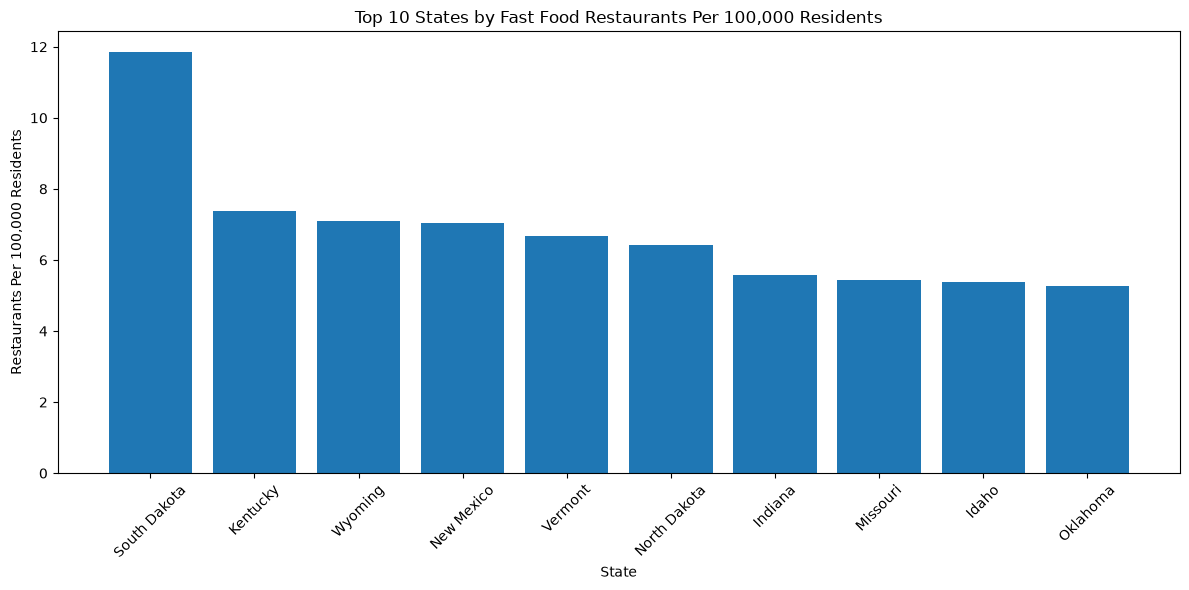

In [23]:
plt.figure(figsize=(12,6))

plt.bar(
    top10["state_name"],
    top10["restaurants_per_100k"]
)

plt.title(
    "Top 10 States by Fast Food Restaurants Per 100,000 Residents"
)

plt.xlabel("State")
plt.ylabel("Restaurants Per 100,000 Residents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question3_top10.png",
    dpi=300
)

plt.show()

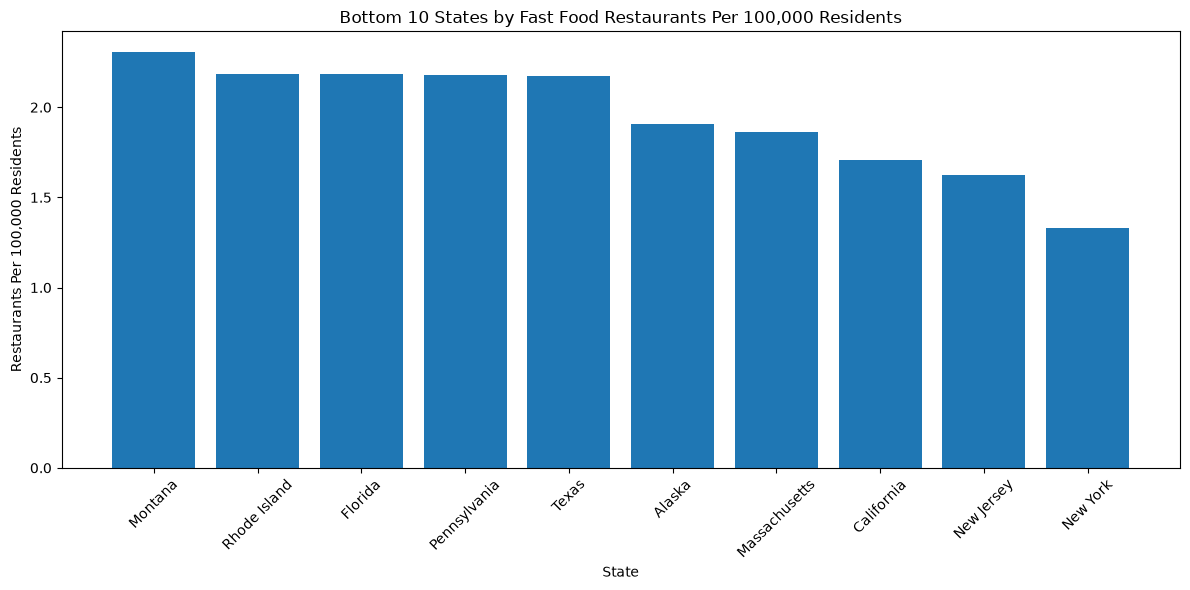

In [24]:
plt.figure(figsize=(12,6))

plt.bar(
    bottom10["state_name"],
    bottom10["restaurants_per_100k"]
)

plt.title(
    "Bottom 10 States by Fast Food Restaurants Per 100,000 Residents"
)

plt.xlabel("State")
plt.ylabel("Restaurants Per 100,000 Residents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question3_bottom10.png",
    dpi=300
)

plt.show()